In [1]:
import pywt
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import h5py
import os

In [2]:
data_path = "../../UCI/data"
FS = 125
wavelet = "db4"
level = 6

In [3]:
from wavelet import wavelet_denoise, plot_dwt_levels, analyze_wavelet_denoising, create_wavelet_dataset

In [4]:
recordings = []

for part in range(1,5):

    file_path = f"{data_path}/Part_{part}.mat"

    f = h5py.File(file_path, "r")

    dataset = f[f"Part_{part}"]


    for i in range(dataset.shape[0]):

        recordings.append(
            (f, dataset[i,0])
        )


print("Total recordings:", len(recordings))

file_handle, recording_ref = recordings[250]

# Dereference the HDF5 reference
recording = file_handle[recording_ref]

Total recordings: 12000


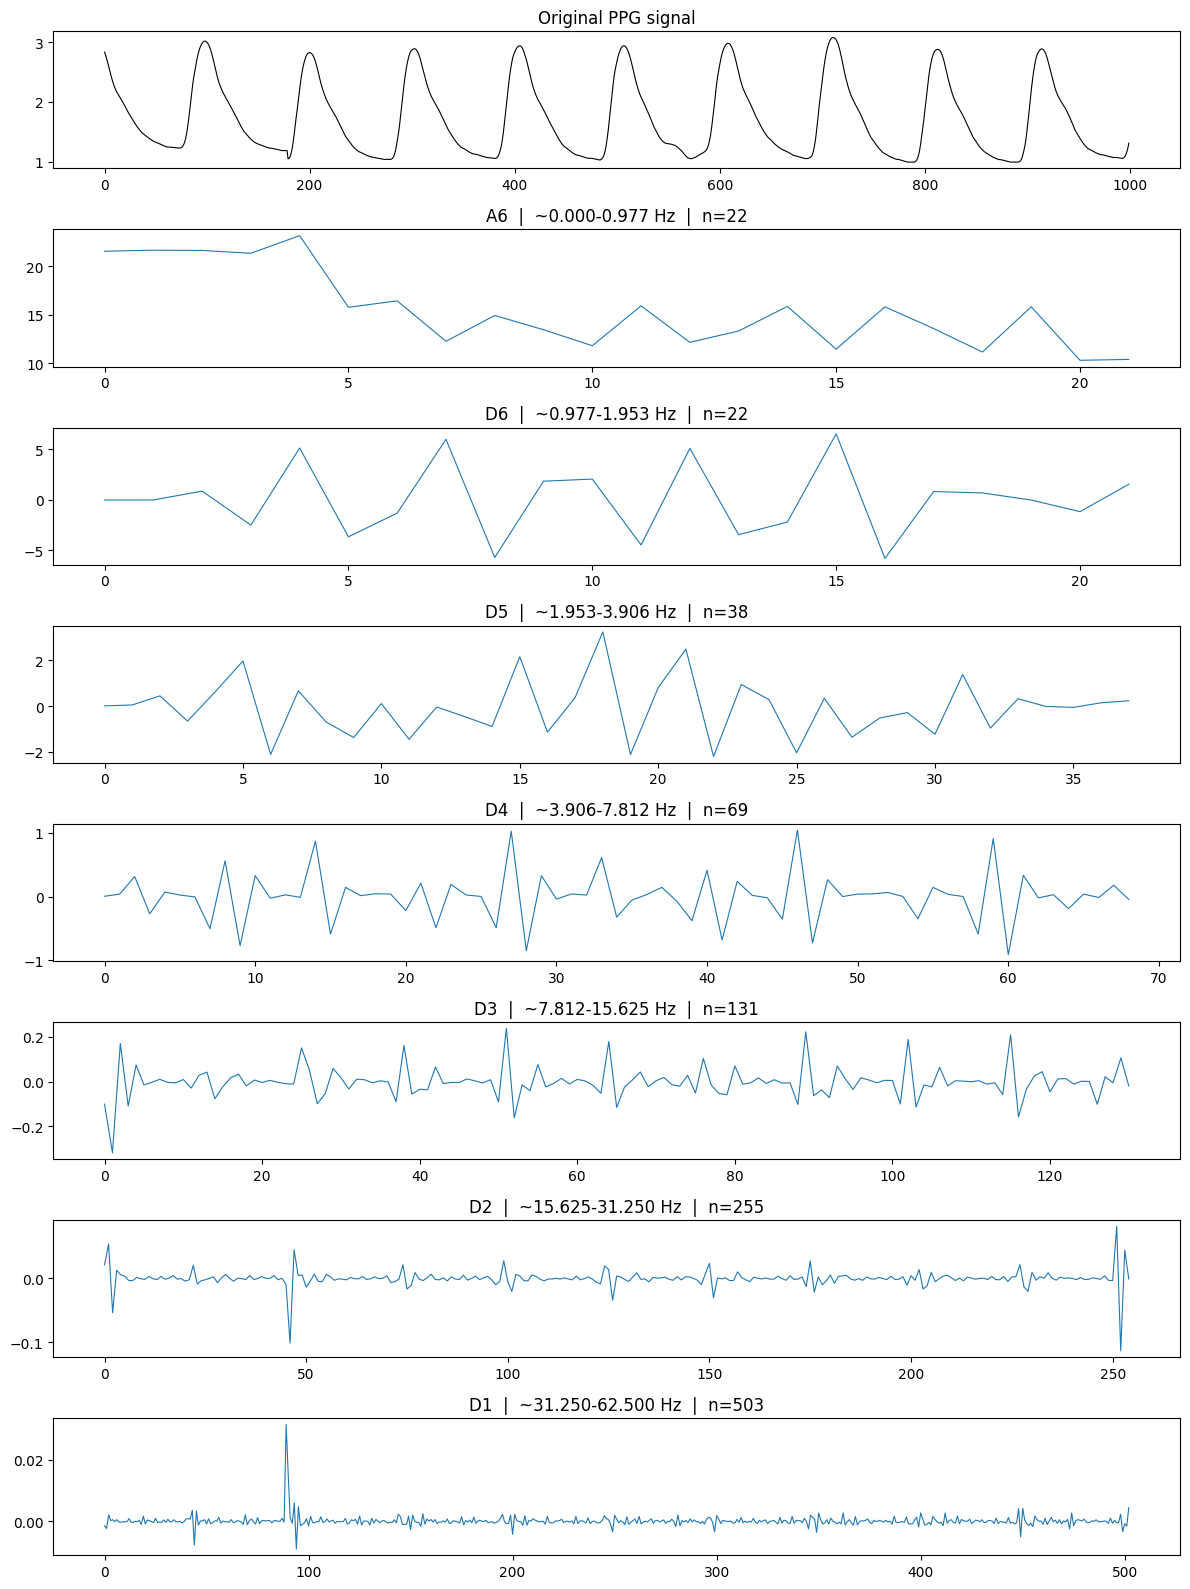

[array([21.51818332, 21.62477028, 21.59679115, 21.31102692, 23.11610342,
        15.75824909, 16.41960374, 12.26347636, 14.91807096, 13.45566627,
        11.81042731, 15.90733932, 12.16110504, 13.3187421 , 15.8480882 ,
        11.45916032, 15.80442523, 13.57067021, 11.16041185, 15.80712749,
        10.31173287, 10.40255456]),
 array([-0.01783869, -0.01455016,  0.86106439, -2.50323444,  5.13458897,
        -3.66790114, -1.31919566,  6.00125117, -5.71910657,  1.84657085,
         2.05578498, -4.47798339,  5.10064073, -3.45335862, -2.20777794,
         6.54776683, -5.81442357,  0.82203062,  0.68004987, -0.02276664,
        -1.17462156,  1.5458025 ]),
 array([ 0.00746093,  0.04708172,  0.44506691, -0.6586348 ,  0.62778929,
         1.97111941, -2.11687256,  0.66721265, -0.69238696, -1.37774881,
         0.10907216, -1.45574064, -0.0431123 , -0.45855365, -0.89271782,
         2.15914654, -1.14293396,  0.37204807,  3.24209245, -2.12185489,
         0.80503933,  2.49225787, -2.20941787,  0.94

In [5]:
ppg = recording[:1000, 0]
plot_dwt_levels(ppg, wavelet=wavelet, level=level, fs=125)

WAVELET DENOISING ANALYSIS

Shape:
Original shape : (71000,)
Denoised shape : (71000,)

Original:
Mean : 1.710811
Std  : 0.643414
Min  : 0.000000
Max  : 3.874878

Denoised:
Mean : -0.000125
Std  : 0.607158
Min  : -1.679188
Max  : 1.708567

Similarity:
Correlation : 0.94357

Residual:
Residual std : 0.213081
Residual / signal std : 33.117%


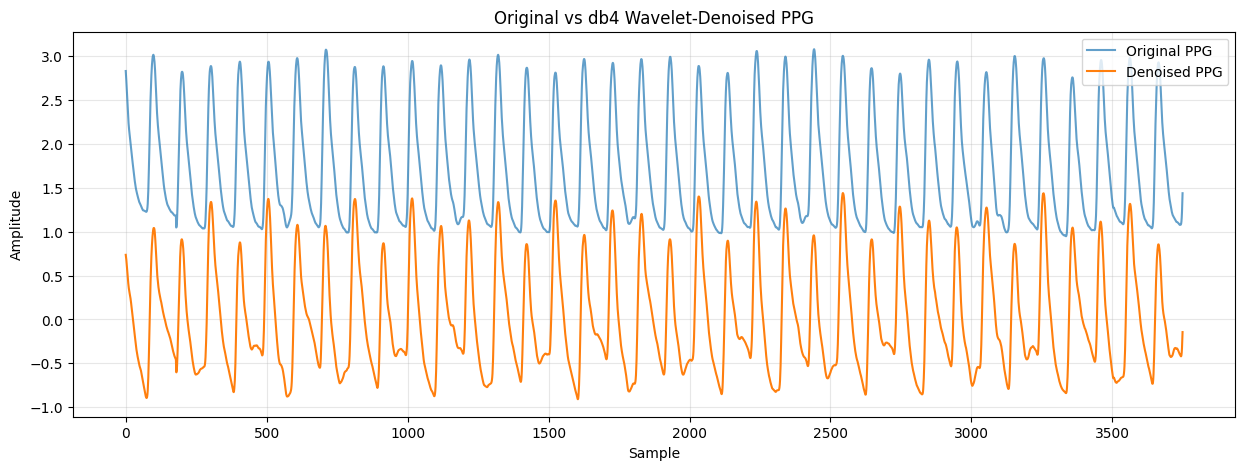

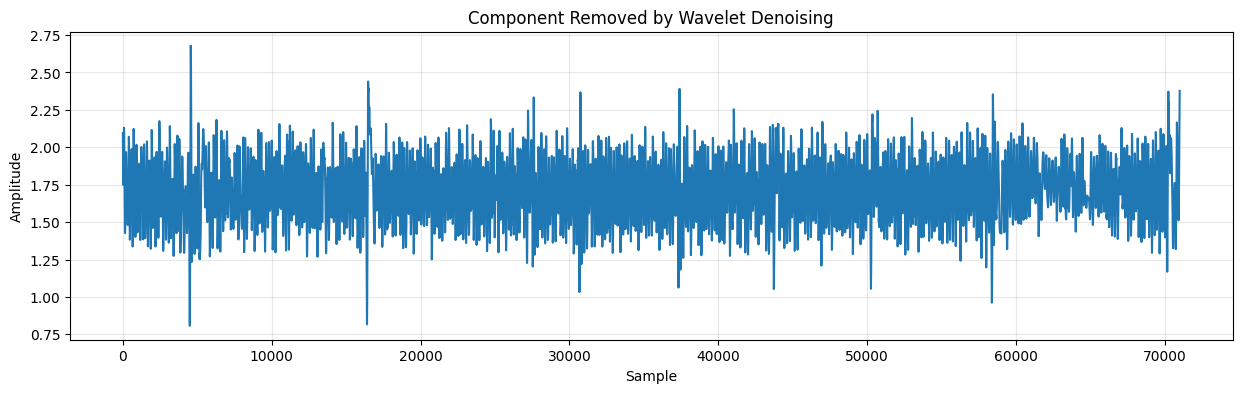

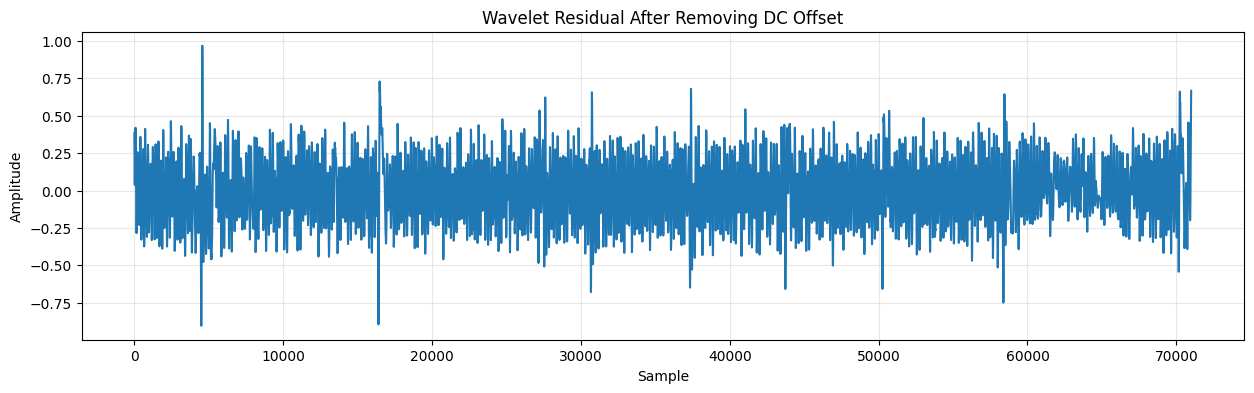

In [6]:
ppg = recording[:, 0]

denoised_ppg = wavelet_denoise(
    ppg,
    wavelet=wavelet,
    level=level
)

results = analyze_wavelet_denoising(
    ppg,
    denoised_ppg,
    wavelets=wavelet,
    fs=125,
    plot_seconds=30
)

In [7]:
DATA_PATH = "../../UCI/data"
WAVELET_PATH = f"/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/PINN/wavelets_data/{wavelet}_{level}"

In [8]:
create_wavelet_dataset(
    input_folder=DATA_PATH,
    output_folder=WAVELET_PATH,
    wavelet=wavelet,
    level=level,
    remove_components=("A",)
)


Processing Part_1.mat
Number of recordings: 3000
  Processed 1 recordings
  Processed 100 recordings
  Processed 200 recordings
  Processed 300 recordings
  Processed 400 recordings
  Processed 500 recordings
  Processed 600 recordings
  Processed 700 recordings
  Processed 800 recordings
  Processed 900 recordings
  Processed 1000 recordings
  Processed 1100 recordings
  Processed 1200 recordings
  Processed 1300 recordings
  Processed 1400 recordings
  Processed 1500 recordings
  Processed 1600 recordings
  Processed 1700 recordings
  Processed 1800 recordings
  Processed 1900 recordings
  Processed 2000 recordings
  Processed 2100 recordings
  Processed 2200 recordings
  Processed 2300 recordings
  Processed 2400 recordings
  Processed 2500 recordings
  Processed 2600 recordings
  Processed 2700 recordings
  Processed 2800 recordings
  Processed 2900 recordings
  Processed 3000 recordings
  Skipped: 0 recordings
  Saved: 3000 recordings
Saved: /data1/yashvi_bhuva/BP_estimation_usin